# 训练阶段

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from YOLOV1 import YOLOV1, YOLOLoss
from data import VOCDataset,NMS, ALL_CLASS,IMAGE_SIZE, img_path, annotations_path
from torch.utils.data import DataLoader
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import cv2

# 训练模型
def train():
    train_loader = DataLoader(
        VOCDataset(img_path=img_path, annotations_path=annotations_path),
        batch_size=8,
        shuffle=True,
        num_workers=4,
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(ALL_CLASS)
    model = YOLOV1(num_classes=num_classes).to(device)
    model.init_weight()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = YOLOLoss(num_classes=num_classes)

    epochs = 10
    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        start_time = time.time()
        epoch_loss = 0
        epoch_xy = 0
        epoch_wh = 0
        epoch_conf = 0
        epoch_class = 0
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            # print(images.shape, labels.shape) # torch.Size([32, 3, 448, 448]) torch.Size([32, 7, 7, 30])
            predictions = model(images)
            # print(predictions.shape) # torch.Size([32, 7, 7, 30])
            # print(predictions.requires_grad) #True
            # print(labels.requires_grad) # False
            loss, xy, wh, conf, cls = criterion(predictions, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_xy += xy.item()
            epoch_wh += wh.item()
            epoch_conf += conf.item()
            epoch_class += cls.item()
            # break
        epoch_losses.append(epoch_loss / len(train_loader))
        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss / len(train_loader):.4f} | XY: {epoch_xy / len(train_loader):.4f} | WH: {epoch_wh / len(train_loader):.4f} | Conf: {epoch_conf / len(train_loader):.4f} | Class: {epoch_class / len(train_loader):.4f}. Time: {time.time() - start_time:.2f}s"
        )
    torch.save(model.state_dict(), "./model/yolov1.pth")

    # 绘制损失曲线
    plt.plot(epoch_losses, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# 测试模型
def evaluate():
    test_loader = DataLoader(
        VOCDataset(img_path=img_path, annotations_path=annotations_path, train=False),
        batch_size=32,
        shuffle=True,
        num_workers=4,
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(ALL_CLASS)
    model = YOLOV1(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load("./model/yolov1.pth"))
    model.eval()
    criterion = YOLOLoss(num_classes=num_classes)

    all_loss = []
    xy_loss = []
    wh_loss = []
    conf_loss = []
    cls_loss = []
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            loss, xy, wh, conf, cls = criterion(predictions, labels)
            all_loss.append(loss.item())
            xy_loss.append(xy.item())
            wh_loss.append(wh.item())
            conf_loss.append(conf.item())
            cls_loss.append(cls.item())

    # 绘制损失曲线
    plt.plot(all_loss, label="Training Loss", color="red")
    plt.plot(xy_loss, label="XY Loss", color="green")
    plt.plot(wh_loss, label="WH Loss", color="blue")
    plt.plot(conf_loss, label="Conf Loss", color="orange")
    plt.plot(cls_loss, label="Class Loss", color="purple")
    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.show()

def draw_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
    tensor_img = torch.tensor(img, dtype=torch.float32) / 255.0  # (448, 448, 3)
    tensor_img = tensor_img.permute(2, 0, 1)  # (3, 448, 448)
    tensor_img = tensor_img.unsqueeze(0)  # (1, 3, 448, 448)
    model = YOLOV1()
    model.load_state_dict(torch.load("./model/yolov1.pth"))
    model.eval()

    with torch.no_grad():
        labels = model(tensor_img)
        # print(labels.shape) # torch.Size([1, 7, 7, 30])
        boxes = labels.squeeze(0)  # (7, 7, 30)
        # print(boxes)
        NMS(boxes)

100%|██████████| 32/32 [00:49<00:00,  1.54s/it]


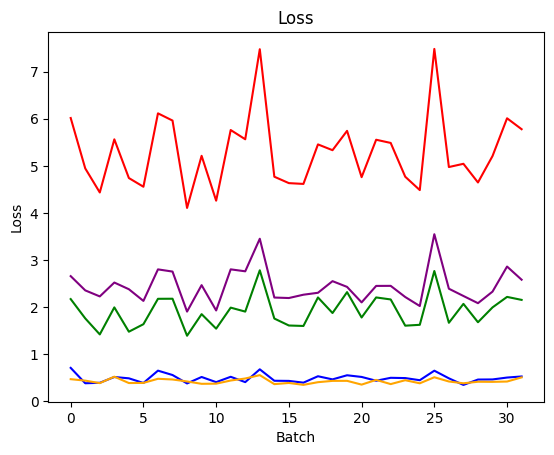

In [10]:
if __name__ == "__main__":
    # train()
    evaluate()

In [2]:
draw_image("D:\my code\yolo_data\VOC2012\JPEGImages\\2007_000027.jpg")

tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(15)
tensor(11)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(15)
tensor(15)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(15)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(16)
tensor(15)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(15)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(15)
tensor(15)
tensor(11)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(15)
tensor(11)
49
[tensor([0.4942, 0.5458, 0.6928, 0.5566, 0.0701, 0.0000]), tensor([0.4147, 0.6082, 0.3985, 0.4816, 0.0492, 0.0000]), tensor([0.5381, 0.5580, 0.4069, 0.4672, 0.0411, 0.0000]), tensor([0.4271, 0.5891, 0.3099, 0.4168, 0.0348, 0.0000]), tensor([0.5667, 0.5862, 0.2937, 0.3825, 0.0338, 0.0000]), tensor([0.4606, 0.3744, 0.5586, 0.4248, 0.0324, 0.0000]), tensor([0.5234, 0.4011, 0.3758, 0.4055, 0.0265, 0.0000]), tensor([0.5359, 0.3765, 0.3582, 0.4136, 0.0245, 0.0000]), tensor([0.5660, 0.4271, 0.264